In [72]:
%load_ext autoreload
%autoreload 2

from scripts.ingestion import *
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [81]:
data_dir = "/Users/jiayi/Princeton Dropbox/Jiayi Zhang/sensetics/03_26_pzr_test"

session_index = build_sessions_index(data_dir)
pzr_columns = ["CH0", "CH1","CH2","CH3","CH4"]

Error occurred while processing session adc_data_20260326_1500: Expected timing CSV not found: /Users/jiayi/Princeton Dropbox/Jiayi Zhang/sensetics/03_26_pzr_test/adc_data_20260326_1456_block_timing.csv
Error occurred while processing session adc_data_20260326_1615: Expected timing CSV not found: /Users/jiayi/Princeton Dropbox/Jiayi Zhang/sensetics/03_26_pzr_test/adc_data_20260326_1611_block_timing.csv
Error occurred while processing session adc_data_20260326_1621: Expected timing CSV not found: /Users/jiayi/Princeton Dropbox/Jiayi Zhang/sensetics/03_26_pzr_test/adc_data_20260326_1618_block_timing.csv
Error occurred while processing session adc_data_20260326_1623: Expected timing CSV not found: /Users/jiayi/Princeton Dropbox/Jiayi Zhang/sensetics/03_26_pzr_test/adc_data_20260326_1621_block_timing.csv


In [83]:
session_index

session_id,x_um,y_um,date_yyyymmdd,time_hhmm,total_captured_sweeps,saved_sweeps,sweeps_per_block,samples_per_block,csv_path,meta_path,timestamp,notes,fs_hz,force_available,x_force_available,z_force_available,total_force_samples,calibration_offset_x,calibration_offset_z,force_note,timing_csv
str,null,null,str,str,i64,i64,i64,i64,str,str,str,str,f64,bool,bool,bool,i64,f64,f64,str,str
"""adc_data_20260326_1507""",null,null,"""20260326""","""1507""",38608,38608,1,5,"""/Users/jiayi/Princeton Dropbox…","""/Users/jiayi/Princeton Dropbox…","""2026-03-26 15:07:58""","""stimulus 1""",1113.585746,false,false,false,0,0.0,0.0,"""Force data not available""","""/Users/jiayi/Princeton Dropbox…"
"""adc_data_20260326_1520""",null,null,"""20260326""","""1520""",213912,213912,1,5,"""/Users/jiayi/Princeton Dropbox…","""/Users/jiayi/Princeton Dropbox…","""2026-03-26 15:20:44""","""no stimulus""",1127.395716,false,false,false,0,0.0,0.0,"""Force data not available""","""/Users/jiayi/Princeton Dropbox…"
"""adc_data_20260326_1537""",null,null,"""20260326""","""1537""",100321,100321,1,5,"""/Users/jiayi/Princeton Dropbox…","""/Users/jiayi/Princeton Dropbox…","""2026-03-26 15:37:58""","""stimulus 2""",1133.786848,false,false,false,0,0.0,0.0,"""Force data not available""","""/Users/jiayi/Princeton Dropbox…"
"""adc_data_20260326_1617""",null,null,"""20260326""","""1617""",111973,111973,1,5,"""/Users/jiayi/Princeton Dropbox…","""/Users/jiayi/Princeton Dropbox…","""2026-03-26 16:17:43""","""stimulus 1, pzr 2""",923.361034,false,false,false,0,0.0,0.0,"""Force data not available""","""/Users/jiayi/Princeton Dropbox…"
"""adc_data_20260326_1625""",null,null,"""20260326""","""1625""",36165,36165,1,5,"""/Users/jiayi/Princeton Dropbox…","""/Users/jiayi/Princeton Dropbox…","""2026-03-26 16:25:08""","""stimulus 2, pzr 3""",671.14094,false,false,false,0,0.0,0.0,"""Force data not available""","""/Users/jiayi/Princeton Dropbox…"


In [84]:
conds = ["no stimulus", "stimulus 1", "stimulus 2", "stimulus 1, pzr 2",
         "stimulus 2, pzr 3"]

### Problem 1: does the baseline drift over time?


In [35]:
def get_baseline(df, ch, fs, t_start, t_end):
    start_idx = int(t_start * fs)
    end_idx = int(t_end * fs)
    data = df[ch].iloc[start_idx:end_idx]
    baseline = data.median()
    return baseline

In [ ]:
# load data for "no stimulus" condition
cond = "no stimulus"

query = pl.col("notes").str.contains(cond)

filtered = session_index.filter(query).to_dicts()[0]
fs = filtered["fs_hz"]
N_cap = filtered["saved_sweeps"]

pdf = load_session_pandas(filtered, columns=pzr_columns)

In [40]:
# compute moving baseline for each channel
baseline_window = 0.5  # seconds
baseline_starts = np.arange(0, len(pdf) / fs, baseline_window/2)
baseline_dict = {}
for ch in pzr_columns:
    baseline_dict[ch] = []
    for t_start in baseline_starts:
        baseline = get_baseline(pdf, ch, fs, t_start=t_start, t_end=t_start + baseline_window)
        baseline_dict[ch].append(baseline)


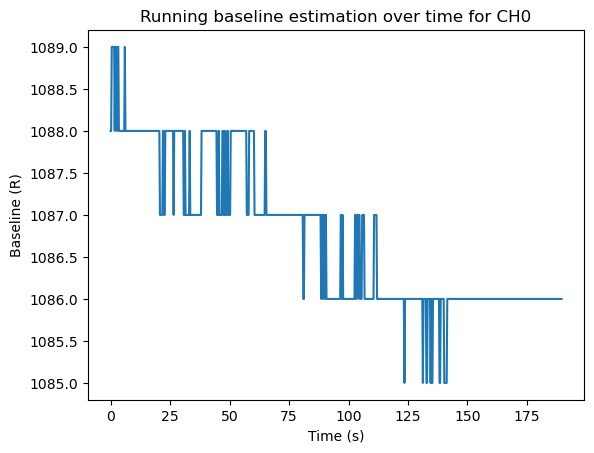

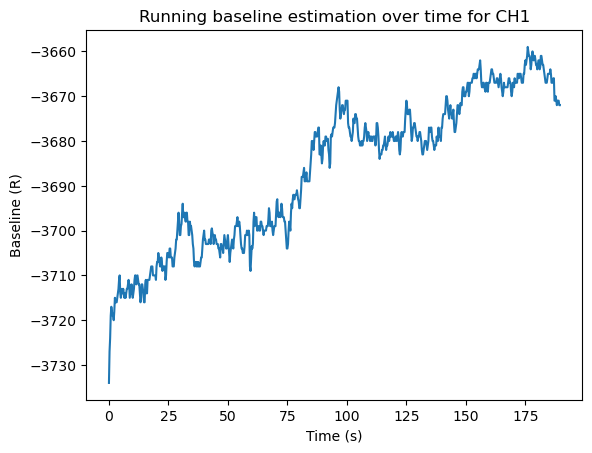

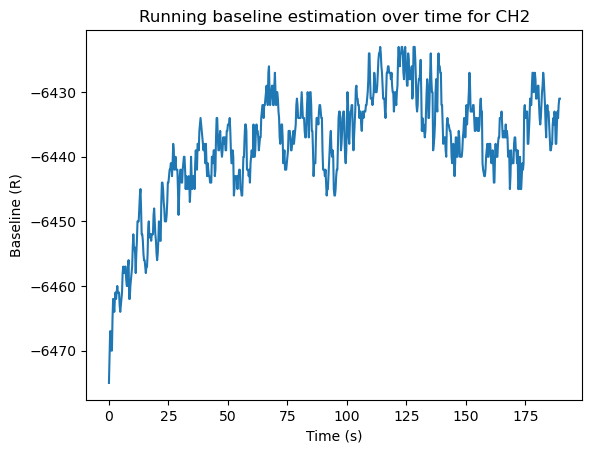

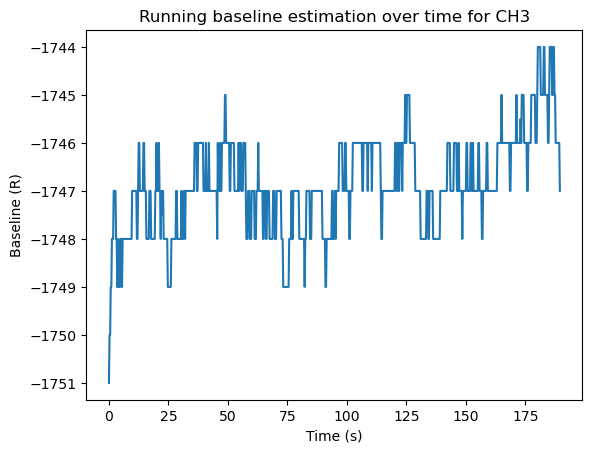

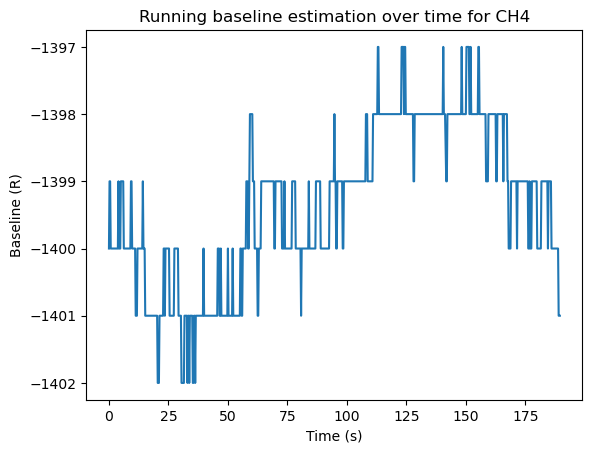

In [59]:
for ch in pzr_columns:
    plt.figure()
    plt.plot(baseline_starts[:], baseline_dict[ch][:])
    plt.title(f"Running baseline estimation over time for {ch}")
    plt.xlabel("Time (s)")
    plt.ylabel("Baseline (R)")
    plt.show()

**Conclusions**: The baselines of channels with smaller biases seem to be more stable over time, while channels with larger biases show (an overall positive) drift. Also there appears to be ~0.5 second settling time after the start of the recording, which should be omitted when computing the baseline for each trial.

### Problem 2: reaction to weight?

In [87]:
# load data
cond = "stimulus 2, pzr 3"
pzr_columns = ["CH10", "CH11","CH12","CH13","CH14"]

query = pl.col("notes").str.contains(cond)

filtered = session_index.filter(query).to_dicts()[0]
fs = filtered["fs_hz"]
N_cap = filtered["saved_sweeps"]

pdf = load_session_pandas(filtered, columns=pzr_columns)

In [88]:
baseline_window = 0.5  # seconds
baseline_start = 1.5
baselines = dict()

pdf_baseline_corrected = pdf.copy()

for ch in pzr_columns:
    baselines[ch] = get_baseline(pdf, ch, fs, t_start=baseline_start, t_end=baseline_start + baseline_window)
    pdf_baseline_corrected[ch] = ((pdf[ch] - baselines[ch]) / baselines[ch]) * 100

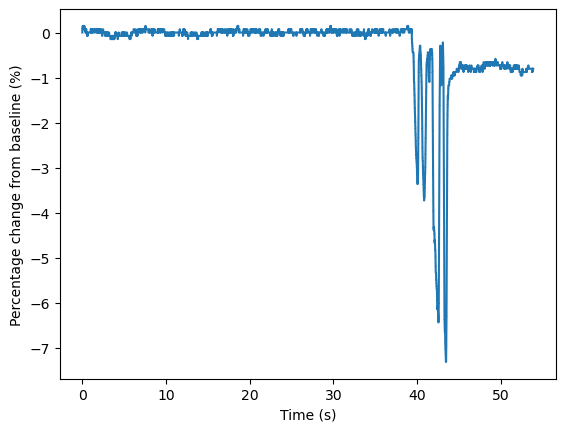

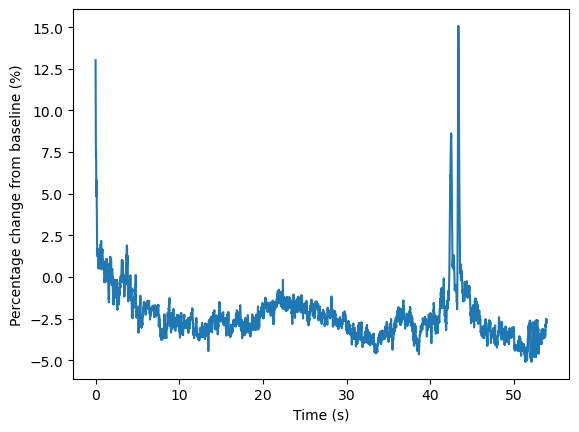

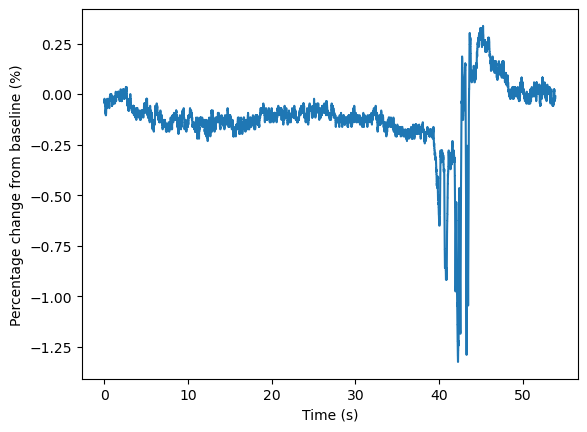

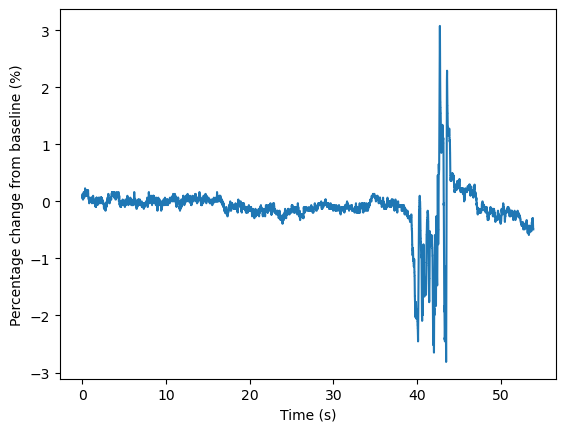

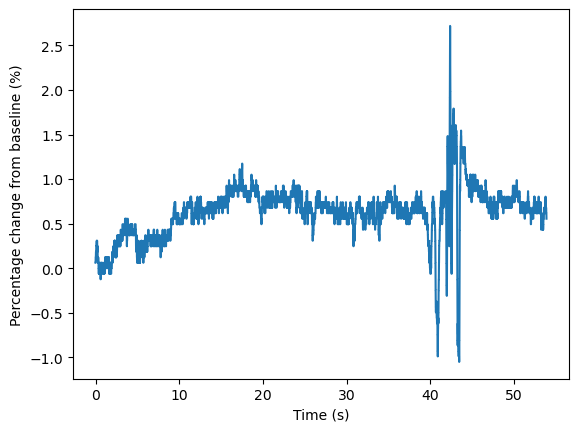

In [89]:
for ch in pzr_columns:
    plt.figure()
    dur = len(pdf[ch]) / fs
    time = np.linspace(0, dur, len(pdf[ch]))
    plt.plot(time, pdf_baseline_corrected[ch])
    plt.ylabel("Percentage change from baseline (%)")
    plt.xlabel("Time (s)")